# Mural Damage Simulator Demo

This notebook demonstrates:

- single-image interactive testing with `ipywidgets`
- side-by-side comparison of multiple damage types on the same image
- batch generation from an image folder and a mask folder


In [1]:
from pathlib import Path
import sys
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "mural_damage_simulator.py").exists():
    raise FileNotFoundError("Run this notebook from the folder that contains mural_damage_simulator.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("ipywidgets is required for the interactive demo. Install it with `pip install ipywidgets`.") from exc

import mural_damage_simulator as mds

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 110

print("PROJECT_ROOT =", PROJECT_ROOT)
print("Available damage types =", mds.DAMAGE_TYPES)


PROJECT_ROOT = /export/data/sfan/gnn
Available damage types = ('base_fill', 'rough_plaster', 'powdered_loss')


In [2]:
DEFAULT_IMAGE_DIRS = [
    PROJECT_ROOT / "images",
    PROJECT_ROOT / "mural-restoration" / "dataset" / "decomp_test" / "albedo",
]
DEFAULT_MASK_DIRS = [
    PROJECT_ROOT / "masks",
    PROJECT_ROOT / "mural-restoration" / "dataset" / "decomp_test" / "mask",
]


def pick_existing(paths: list[Path]) -> Path:
    for path in paths:
        if path.exists():
            return path
    return paths[0]


IMAGE_DIR = pick_existing(DEFAULT_IMAGE_DIRS)
MASK_DIR = pick_existing(DEFAULT_MASK_DIRS)
OUTPUT_DIR = PROJECT_ROOT / "damage_demo_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Edit these paths here if needed:")
print("IMAGE_DIR =", IMAGE_DIR)
print("MASK_DIR  =", MASK_DIR)
print("OUTPUT_DIR=", OUTPUT_DIR)


Edit these paths here if needed:
IMAGE_DIR = /export/data/sfan/gnn/mural-restoration/dataset/decomp_test/albedo
MASK_DIR  = /export/data/sfan/gnn/mural-restoration/dataset/decomp_test/mask
OUTPUT_DIR= /export/data/sfan/gnn/damage_demo_outputs


In [3]:
def list_supported_files(directory: Path) -> list[Path]:
    directory = Path(directory)
    if not directory.exists():
        return []
    files = [path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in mds.SUPPORTED_IMAGE_EXTENSIONS]
    return sorted(files)


def refresh_options() -> tuple[list[Path], list[Path]]:
    image_files = list_supported_files(IMAGE_DIR)
    mask_files = list_supported_files(MASK_DIR)
    if not image_files:
        raise FileNotFoundError(f"No supported images found in {IMAGE_DIR}")
    if not mask_files:
        raise FileNotFoundError(f"No supported masks found in {MASK_DIR}")
    return image_files, mask_files


def preview_once(
    image_path: Path,
    mask_path: Path,
    damage_type: str,
    noise_strength: float,
    noise_scale: float,
    opacity: float,
    edge_sharpness: float,
    seed: int,
    ring_width: int,
):
    image = mds.load_image(image_path)
    mask = mds.load_mask(mask_path, target_shape=image.shape[:2])
    result, info = mds.apply_damage(
        image=image,
        mask=mask,
        damage_type=damage_type,
        noise_strength=noise_strength,
        noise_scale=noise_scale,
        opacity=opacity,
        edge_sharpness=edge_sharpness,
        seed=seed,
        ring_width=ring_width,
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[1].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Mask")
    axes[2].imshow(result)
    axes[2].set_title(damage_type)
    for ax in axes:
        ax.axis("off")
    fig.tight_layout()
    plt.show()

    print("status =", info["status"])
    print("base_color =", np.round(np.asarray(info["base_color"]), 4).tolist())
    print("nonzero_mask_pixels =", info.get("nonzero_mask_pixels"))
    return image, mask, result, info


In [4]:
image_files, mask_files = refresh_options()

image_dropdown = widgets.Dropdown(
    options=[(path.name, path) for path in image_files],
    value=image_files[0],
    description="Image:",
    layout=widgets.Layout(width="420px"),
)
mask_dropdown = widgets.Dropdown(
    options=[(path.name, path) for path in mask_files],
    value=mask_files[0],
    description="Mask:",
    layout=widgets.Layout(width="420px"),
)
damage_dropdown = widgets.Dropdown(
    options=list(mds.DAMAGE_TYPES),
    value="rough_plaster",
    description="Type:",
    layout=widgets.Layout(width="250px"),
)
noise_strength_slider = widgets.FloatSlider(value=0.35, min=0.0, max=1.2, step=0.01, description="Noise", readout_format=".2f", continuous_update=False)
noise_scale_slider = widgets.FloatSlider(value=32.0, min=4.0, max=128.0, step=1.0, description="Scale", readout_format=".0f", continuous_update=False)
opacity_slider = widgets.FloatSlider(value=1.0, min=0.0, max=1.0, step=0.01, description="Opacity", readout_format=".2f", continuous_update=False)
edge_sharpness_slider = widgets.FloatSlider(value=0.7, min=0.0, max=1.0, step=0.01, description="Edge", readout_format=".2f", continuous_update=False)
ring_width_slider = widgets.IntSlider(value=9, min=1, max=32, step=1, description="Ring")
seed_widget = widgets.IntText(value=123, description="Seed:")
run_button = widgets.Button(description="Run Preview", button_style="primary")
output_widget = widgets.Output()


def run_preview(_=None):
    with output_widget:
        clear_output(wait=True)
        preview_once(
            image_path=image_dropdown.value,
            mask_path=mask_dropdown.value,
            damage_type=damage_dropdown.value,
            noise_strength=float(noise_strength_slider.value),
            noise_scale=float(noise_scale_slider.value),
            opacity=float(opacity_slider.value),
            edge_sharpness=float(edge_sharpness_slider.value),
            seed=int(seed_widget.value),
            ring_width=int(ring_width_slider.value),
        )


run_button.on_click(run_preview)

controls_left = widgets.VBox([image_dropdown, mask_dropdown, damage_dropdown])
controls_right = widgets.VBox([
    noise_strength_slider,
    noise_scale_slider,
    opacity_slider,
    edge_sharpness_slider,
    ring_width_slider,
    seed_widget,
    run_button,
])

display(widgets.HBox([controls_left, controls_right]))
display(output_widget)
run_preview()


Output()

## Compare All Damage Types on the Same Image

Use the currently selected image, mask, and widget parameters to show all damage modes side by side.


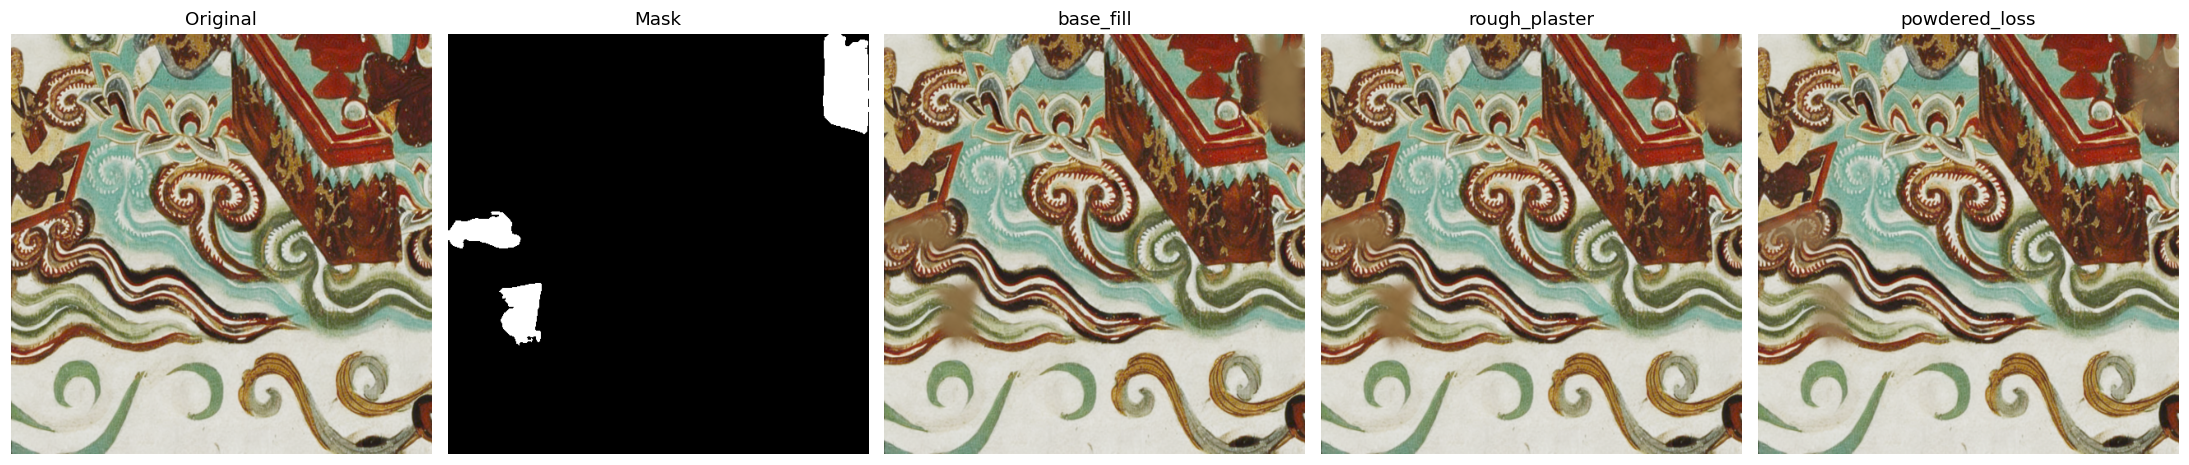

In [5]:
compare_image = mds.load_image(image_dropdown.value)
compare_mask = mds.load_mask(mask_dropdown.value, target_shape=compare_image.shape[:2])

compare_results = {}
for damage_type in mds.DAMAGE_TYPES:
    compare_result, _ = mds.apply_damage(
        image=compare_image,
        mask=compare_mask,
        damage_type=damage_type,
        noise_strength=float(noise_strength_slider.value),
        noise_scale=float(noise_scale_slider.value),
        opacity=float(opacity_slider.value),
        edge_sharpness=float(edge_sharpness_slider.value),
        seed=int(seed_widget.value),
        ring_width=int(ring_width_slider.value),
    )
    compare_results[damage_type] = compare_result

mds.show_comparison(compare_image, compare_mask, compare_results, figsize=(4.0 * (len(compare_results) + 2), 4.8))
plt.show()


## Batch Processing for DhMurals Test Set

This cell reads `/export/data/sfan/gnn/mural-restoration/dataset/DhMurals-inpainting-dataset/test/images` and `/export/data/sfan/gnn/mural-restoration/dataset/DhMurals-inpainting-dataset/test/masks`, pairs files by stem, applies one randomly sampled damage type per image, and saves exactly one damaged result per source image into `damaged_albedo`.


In [6]:
import csv
import json
import cv2

DATASET_ROOT = Path("/export/data/sfan/gnn/mural-restoration/dataset/DhMurals-inpainting-dataset/train_sub")
PAIRED_IMAGE_DIR = DATASET_ROOT / "intrinsics" / "albedo"
PAIRED_MASK_DIR = DATASET_ROOT / "masks"
DAMAGED_ALBEDO_DIR = DATASET_ROOT / "damaged_albedo"
DAMAGED_ALBEDO_DIR.mkdir(parents=True, exist_ok=True)

noise_strength_range = (0.50, 0.90)
noise_scale_range = (10.0, 50.0)
opacity_range = (0.95, 1.0)
edge_sharpness_range = (0.80, 0.95)
ring_width = 9
seed = 2

for existing in DAMAGED_ALBEDO_DIR.iterdir():
    if existing.is_file() and (
        existing.suffix.lower() in mds.SUPPORTED_IMAGE_EXTENSIONS
        or existing.name in {"damage_metadata.json", "damage_metadata.csv"}
    ):
        existing.unlink()

rng = np.random.default_rng(seed)
image_paths = list_supported_files(PAIRED_IMAGE_DIR)
mask_paths = list_supported_files(PAIRED_MASK_DIR)
mask_lookup = {path.stem: path for path in mask_paths}

paired_paths = [(image_path, mask_lookup[image_path.stem]) for image_path in image_paths if image_path.stem in mask_lookup]
missing_masks = [image_path.name for image_path in image_paths if image_path.stem not in mask_lookup]

if not paired_paths:
    raise FileNotFoundError("No matching image/mask pairs were found in the DhMurals test set.")
if missing_masks:
    print("Warning: missing masks for", missing_masks)


records = []
for image_path, mask_path in paired_paths:
    image = mds.load_image(image_path)
    mask = mds.load_mask(mask_path, target_shape=image.shape[:2])
    local_seed = int(rng.integers(0, np.iinfo(np.int32).max))
    damage_type = str(rng.choice(mds.DAMAGE_TYPES))
    noise_strength = float(rng.uniform(*sorted(noise_strength_range)))
    noise_scale = float(rng.uniform(*sorted(noise_scale_range)))
    opacity = float(rng.uniform(*sorted(opacity_range)))
    edge_sharpness = float(rng.uniform(*sorted(edge_sharpness_range)))

    result, info = mds.apply_damage(
        image=image,
        mask=mask,
        damage_type=damage_type,
        noise_strength=noise_strength,
        noise_scale=noise_scale,
        opacity=opacity,
        edge_sharpness=edge_sharpness,
        seed=local_seed,
        ring_width=ring_width,
    )

    output_path = DAMAGED_ALBEDO_DIR / image_path.name
    output_bgr = cv2.cvtColor((np.clip(result, 0.0, 1.0) * 255.0 + 0.5).astype(np.uint8), cv2.COLOR_RGB2BGR)
    ok = cv2.imwrite(str(output_path), output_bgr)
    if not ok:
        raise IOError(f"Failed to save damaged image to {output_path}")

    base_color = np.asarray(info["base_color"], dtype=np.float32)
    records.append({
        "source_image_path": str(image_path),
        "mask_path": str(mask_path),
        "output_path": str(output_path),
        "damage_type": damage_type,
        "seed": local_seed,
        "noise_strength": noise_strength,
        "noise_scale": noise_scale,
        "opacity": opacity,
        "edge_sharpness": edge_sharpness,
        "ring_width": ring_width,
        "status": str(info["status"]),
        "base_color_r": float(base_color[0]),
        "base_color_g": float(base_color[1]),
        "base_color_b": float(base_color[2]),
    })

metadata_json_path = DAMAGED_ALBEDO_DIR / "damage_metadata.json"
metadata_csv_path = DAMAGED_ALBEDO_DIR / "damage_metadata.csv"

with metadata_json_path.open("w", encoding="utf-8") as handle:
    json.dump(records, handle, ensure_ascii=False, indent=2)

with metadata_csv_path.open("w", encoding="utf-8", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(records[0].keys()))
    writer.writeheader()
    writer.writerows(records)

print(f"Matched image/mask pairs: {len(paired_paths)}")
print(f"Saved damaged images   : {len(records)}")
print("Output folder         :", DAMAGED_ALBEDO_DIR)
print("Metadata JSON         :", metadata_json_path)
print("Metadata CSV          :", metadata_csv_path)
pprint(records[:3])


Matched image/mask pairs: 1000
Saved damaged images   : 1000
Output folder         : /export/data/sfan/gnn/mural-restoration/dataset/DhMurals-inpainting-dataset/train_sub/damaged_albedo
Metadata JSON         : /export/data/sfan/gnn/mural-restoration/dataset/DhMurals-inpainting-dataset/train_sub/damaged_albedo/damage_metadata.json
Metadata CSV          : /export/data/sfan/gnn/mural-restoration/dataset/DhMurals-inpainting-dataset/train_sub/damaged_albedo/damage_metadata.csv
[{'base_color_b': 0.658823549747467,
  'base_color_g': 0.7647058963775635,
  'base_color_r': 0.8156862854957581,
  'damage_type': 'base_fill',
  'edge_sharpness': 0.8900150788948481,
  'mask_path': '/export/data/sfan/gnn/mural-restoration/dataset/DhMurals-inpainting-dataset/train_sub/masks/0-0-1.png',
  'noise_scale': 42.569029623771215,
  'noise_strength': 0.6193964573656493,
  'opacity': 0.9545957971067548,
  'output_path': '/export/data/sfan/gnn/mural-restoration/dataset/DhMurals-inpainting-dataset/train_sub/damage